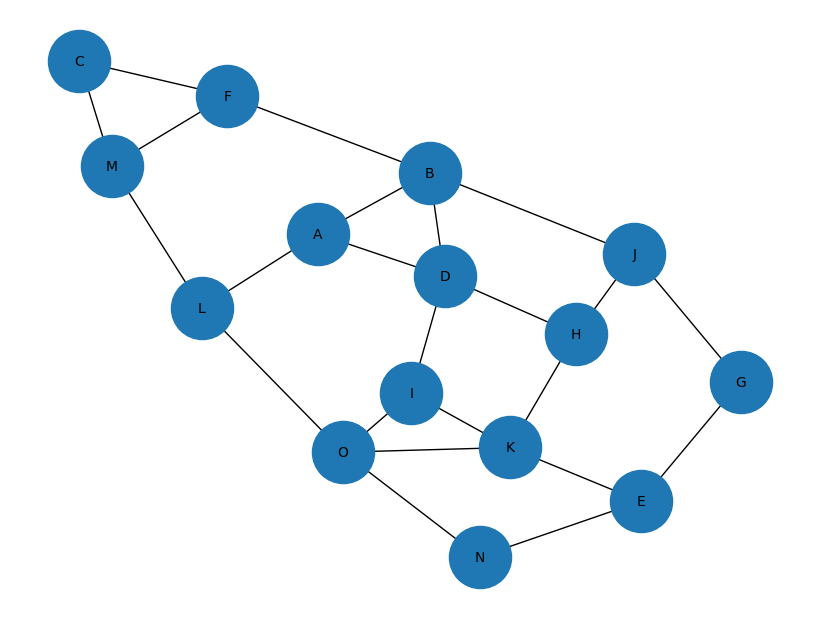

In [64]:
import networkx as nx
import matplotlib.pyplot as plt
import random as random

random.seed(44)
G = nx.Graph()

districts = list("ABCDEFGHIJKLMNO")
G.add_nodes_from(districts)

edges = [
    ('A', 'B'), ('A', 'D'), ('A', 'L'), 
    ('B', 'F'), ('B', 'J'), ('B', 'D'),
    ('C', 'F'), ('C', 'M'),
    ('D', 'H'), ('D', 'I'),
    ('E', 'K'), ('E', 'G'), ('E', 'N'), 
    ('G', 'J'), 
    ('H', 'J'), ('H', 'K'),
    ('I', 'K'), ('I', 'O'),
    ('K', 'O'), 
    ('L', 'O'), ('L', 'M'), 
    ('M', 'F'),
    ('N', 'O'),
]

G.add_edges_from(edges)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()




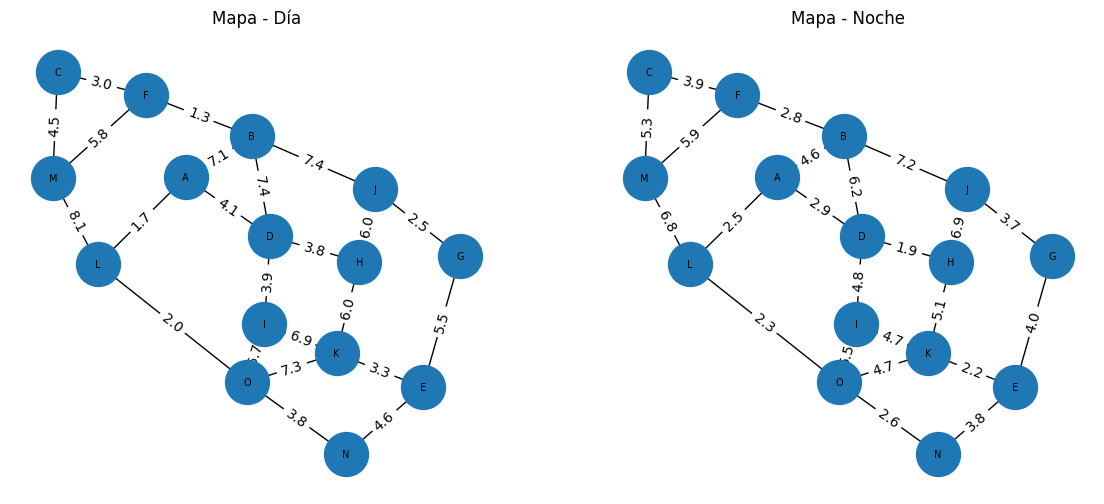

In [66]:

random.seed(44)

for u, v in edges:
    base_violence = random.randint(1, 6)
    extra_day_violence = random.choice([0, 1, 2, 3, 4, 5])

    base_terrain = random.randint(1, 6)
    extra_night_terrain = random.choice([1, 2, 3, 4, 5])

    G.add_edge(
        u, v,
        violence_night=base_violence,
        violence_day=base_violence + extra_day_violence,
        terrain_day=base_terrain,
        terrain_night=base_terrain + extra_night_terrain
    )

def compute_weight(attrs, time_of_day='day'):
    if time_of_day == 'day':
        violence = attrs['violence_day']
        terrain = attrs['terrain_day']
    else:
        violence = attrs['violence_night']
        terrain = attrs['terrain_night']

    return round(
        0.7 * violence + 0.3 * terrain,
        2
    )

def apply_weights(G, time_of_day='day'):
    for u, v, attrs in G.edges(data=True):
        attrs['weight'] = compute_weight(attrs, time_of_day)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

pos = nx.spring_layout(G, seed=42)

# 🔵 Día
apply_weights(G, 'day')
nx.draw(G, pos, ax=axes[0], with_labels=True, node_size=1000, font_size=7)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[0])
axes[0].set_title("Mapa - Día")

# 🌙 Noche
apply_weights(G, 'night')
nx.draw(G, pos, ax=axes[1], with_labels=True, node_size=1000, font_size=7)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[1])
axes[1].set_title("Mapa - Noche")

plt.show()

In [69]:
random.seed(44)

def supplies_needed(path):
    return len(path) - 1

def evaluate_option(G, origin, destination, supplies, time_of_day):
    apply_weights(G, time_of_day)
    path = nx.shortest_path(G, origin, destination, weight='weight')
    cost = nx.shortest_path_length(G, origin, destination, weight='weight')
    needed = supplies_needed(path)
    feasible = needed <= supplies

    return {
        "time_of_day": time_of_day,
        "path": path,
        "cost": cost,
        "supplies_needed": needed,
        "feasible": feasible
    }

def best_time_to_travel(G, origin, destination, supplies):
    day_result = evaluate_option(G, origin, destination, supplies, 'day')
    night_result = evaluate_option(G, origin, destination, supplies, 'night')

    if day_result["feasible"] and not night_result["feasible"]:
        return {
            "best_option": "day",
            "best_path": day_result["path"],
            "best_cost": day_result["cost"],
            "supplies_needed": day_result["supplies_needed"],
            "day_result": day_result,
            "night_result": night_result
        }

    elif night_result["feasible"] and not day_result["feasible"]:
        return {
            "best_option": "night",
            "best_path": night_result["path"],
            "best_cost": night_result["cost"],
            "supplies_needed": night_result["supplies_needed"],
            "day_result": day_result,
            "night_result": night_result
        }

    elif day_result["feasible"] and night_result["feasible"]:
        if day_result["cost"] <= night_result["cost"]:
            return {
                "best_option": "day",
                "best_path": day_result["path"],
                "best_cost": day_result["cost"],
                "supplies_needed": day_result["supplies_needed"],
                "day_result": day_result,
                "night_result": night_result
            }
        else:
            return {
                "best_option": "night",
                "best_path": night_result["path"],
                "best_cost": night_result["cost"],
                "supplies_needed": night_result["supplies_needed"],
                "day_result": day_result,
                "night_result": night_result
            }

    else:
        return {
            "best_option": "impossible",
            "best_path": None,
            "best_cost": None,
            "supplies_needed": None,
            "day_result": day_result,
            "night_result": night_result
        }
    
result = best_time_to_travel(G, 'A', 'O', 1)

print("Best option:", result["best_option"])
print("Best path:", result["best_path"])
print("Best cost:", result["best_cost"])
print("Supplies needed:", result["supplies_needed"])
print("Day result:", result["day_result"])
print("Night result:", result["night_result"])
    



Best option: impossible
Best path: None
Best cost: None
Supplies needed: None
Day result: {'time_of_day': 'day', 'path': ['A', 'L', 'O'], 'cost': 3.7, 'supplies_needed': 2, 'feasible': False}
Night result: {'time_of_day': 'night', 'path': ['A', 'L', 'O'], 'cost': 4.8, 'supplies_needed': 2, 'feasible': False}


In [74]:
random.seed(44)

import pandas as pd

data = []
districts = list(G.nodes())

for _ in range(1000):
    origin, destination = random.sample(districts, 2)
    supplies = random.randint(1, 8)

    result = best_time_to_travel(G, origin, destination, supplies)

    data.append({
        "origin": origin,
        "destination": destination,
        "supplies": supplies,
        "best_option": result["best_option"],
        "best_path": result["best_path"]
    })

df = pd.DataFrame(data)
print(df.head(20))

df.to_csv("military_routes_dataset.csv", index=False)

   origin destination  supplies best_option           best_path
0       G           I         2  impossible                None
1       C           G         4         day     [C, F, B, J, G]
2       E           A         4       night     [E, N, O, L, A]
3       B           J         1       night              [B, J]
4       B           C         5         day           [B, F, C]
5       L           K         7       night           [L, O, K]
6       J           G         6         day              [J, G]
7       F           B         6         day              [F, B]
8       N           E         3       night              [N, E]
9       B           I         2       night           [B, D, I]
10      J           B         5       night              [J, B]
11      F           B         5         day              [F, B]
12      A           F         7       night           [A, B, F]
13      B           H         8       night           [B, D, H]
14      O           D         4       ni

In [83]:
random.seed(44)

X = df[["origin", "destination", "supplies"]]
y = df["best_option"]

X_encoded = pd.get_dummies(X, columns=["origin", "destination"])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

from sklearn.neural_network import MLPClassifier
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(df["best_option"].value_counts())

origin = input("Give me an origin: ").upper()
destination = input("Give me the destination: ").upper()
supplies = int(input("Give me the supplies: "))

new_case = pd.DataFrame([{
    "origin": origin,
    "destination": destination,
    "supplies": supplies
}])

new_case_encoded = pd.get_dummies(new_case, columns=["origin", "destination"])
new_case_encoded = new_case_encoded.reindex(columns=X_encoded.columns, fill_value=0)

prediction = model.predict(new_case_encoded)
predicted_label = label_encoder.inverse_transform(prediction)[0]

print("Predicted best option:", predicted_label)

if predicted_label != "impossible":
    apply_weights(G, predicted_label)
    path = nx.shortest_path(G, origin, destination, weight="weight")
    needed = len(path) - 1

    print("Final path:", path)
    print("Supplies needed:", needed)

    if needed <= supplies:
        print("Final decision:", predicted_label)
        print("Mission is feasible.")
    else:
        print("Predicted time was not feasible with given supplies.")
        print("Mission is NOT feasible with current supplies.")
else:
    print("Final decision: impossible")
    print("Mission is impossible with current supplies.")



Accuracy: 0.935
              precision    recall  f1-score   support

         day       0.95      0.97      0.96        40
  impossible       0.89      0.81      0.85        42
       night       0.94      0.97      0.95       118

    accuracy                           0.94       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.94      0.93       200

best_option
night         593
day           233
impossible    174
Name: count, dtype: int64
Predicted best option: day
Final path: ['M', 'F', 'B', 'J', 'G']
Supplies needed: 4
Final decision: day
Mission is feasible.
